# Proyecto EcommerceDB

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

SERVER_NAME = 'DESKTOP-8KL6HDP\\SQLEXPRESS'
DATABASE_NAME = 'EcommerceDB'

params = urllib.parse.quote_plus(
    f'Driver={{ODBC Driver 17 for SQL Server}};'  
    f'Server={SERVER_NAME};'
    f'Database={DATABASE_NAME};'
    f'Trusted_Connection=yes;'
    f'TrustServerCertificate=yes;'               
)
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

archivos = {
    'olist_customers_dataset.csv': 'clientes',
    'olist_orders_dataset.csv': 'ordenes',
    'olist_order_items_dataset.csv': 'items_orden'
}

for archivo, nombre_tabla in archivos.items():
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.lower()
    df.to_sql(nombre_tabla, con=engine, if_exists='replace', index=False)
print("finalizado")

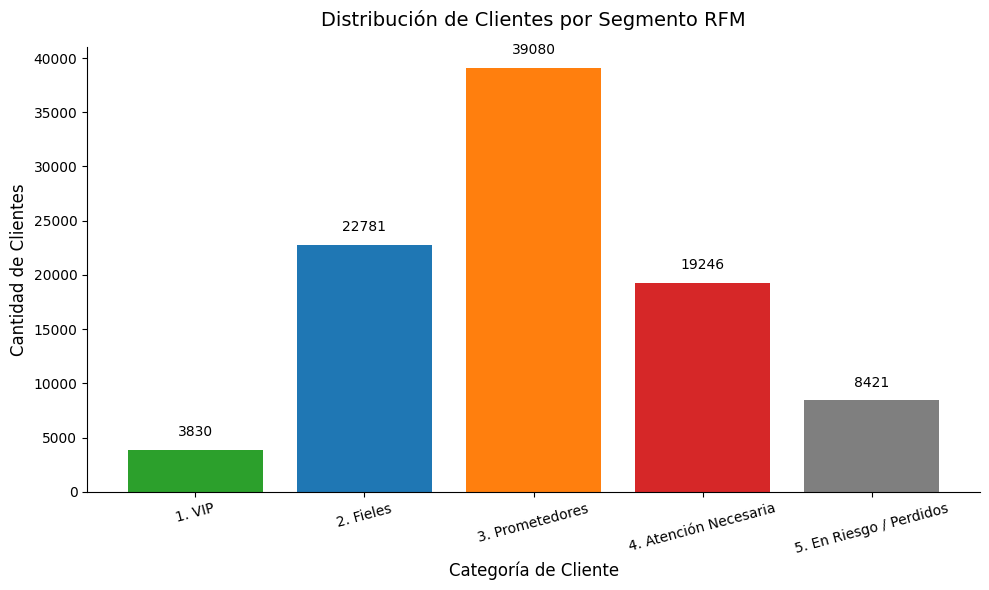

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import urllib

SERVER_NAME = 'DESKTOP-8KL6HDP\\SQLEXPRESS'
DATABASE_NAME = 'EcommerceDB'

params = urllib.parse.quote_plus(
    f'Driver={{ODBC Driver 17 for SQL Server}};'
    f'Server={SERVER_NAME};'
    f'Database={DATABASE_NAME};'
    f'Trusted_Connection=yes;'
    f'TrustServerCertificate=yes;'
)
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

query = """
    SELECT 
        c.customer_unique_id,
        o.order_purchase_timestamp,
        i.price
    FROM ordenes o
    JOIN clientes c ON o.customer_id = c.customer_id
    JOIN items_orden i ON o.order_id = i.order_id
    WHERE o.order_status = 'delivered'
"""
df = pd.read_sql(query, engine)

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp']) # Convertimos a datetime para poder hacer calculos de tiempo

fecha_referencia = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1) 

# Agrupamos por cliente y calculamos U, F y M
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (fecha_referencia - x.max()).days, # Ultimacompra: dias desde la úultima compra
    'customer_unique_id': 'count',                                           # Frecuencia_de_compras: cantidad de compras
    'price': 'sum'                                                           # Monto_total: total gastado
}).rename(columns={
    'order_purchase_timestamp': 'Ultimacompra',
    'customer_unique_id': 'Frecuencia_de_compras',
    'price': 'Monto_total'
})

# Dividimos a los clientes en 5 grupos para cada métrica.
rfm['R_Score'] = pd.qcut(rfm['Ultimacompra'], 5, labels=[5, 4, 3, 2, 1]) # Invertimos las etiquetas debido a que es mejor saber QUIENES compraron hace poco.

rfm['F_Score'] = pd.qcut(rfm['Frecuencia_de_compras'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monto_total'], 5, labels=[1, 2, 3, 4, 5])
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

#Categoria de cliente
def segmentar_cliente(score):
    if score >= 14: return '1. VIP'
    elif score >= 11: return '2. Fieles'
    elif score >= 8: return '3. Prometedores'
    elif score >= 6: return '4. Atención Necesaria'
    else: return '5. En Riesgo / Perdidos'

rfm['Segmento'] = rfm['RFM_Score'].apply(segmentar_cliente)

# ==============================================================================
# Visualizacion
segment_counts = rfm['Segmento'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_counts.index, segment_counts.values, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#7f7f7f'])

plt.title('Distribución de Clientes por Segmento RFM', fontsize=14, pad=15)
plt.xlabel('Categoría de Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=15)

# Agregamos los numeros arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, int(yval), ha='center', va='bottom', fontsize=10)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()